In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

SEED = 42
warnings.filterwarnings("ignore")


Load data — Pulling in the BigMart training set straight from the GitHub raw link.

In [39]:
# Load data — Pulling in the BigMart training set straight from the GitHub raw link.
URL = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_train.csv"
df = pd.read_csv(URL)
df.shape

(8523, 12)

df.head/info/describe/isnull — Item_Weight has ~17% missing and Outlet_Size has ~28% missing — not small enough to just drop rows. Will handle them separately since one's numeric and one's categorical.

In [40]:
# df.head / info / describe / isnull — Item_Weight has ~17% missing and Outlet_Size has ~28% missing — not small enough to just drop rows. Will handle them separately since one's numeric and one's categorical.
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [42]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [43]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Item_Weight has ~17% missing and Outlet_Size has ~28% missing — not small enough to just drop rows. Will handle separately since they're different types.

groupby Outlet_Size — All the missing Outlet_Size values turn out to be Grocery Stores and Supermarket Type1 — so filling with the mode per outlet type makes sense rather than a global fill. 

In [44]:

df.groupby('Outlet_Type')['Outlet_Size'].value_counts(dropna=False)

Outlet_Type        Outlet_Size
Grocery Store      NaN             555
                   Small           528
Supermarket Type1  Small          1860
                   NaN            1855
                   High            932
                   Medium          930
Supermarket Type2  Medium          928
Supermarket Type3  Medium          935
Name: count, dtype: int64

3-panel histplot — Sales is heavily right-skewed with a long tail of high values. log1p pulls it close to normal, so I'll train on the log target and expm1 back at the end — should help all the models.

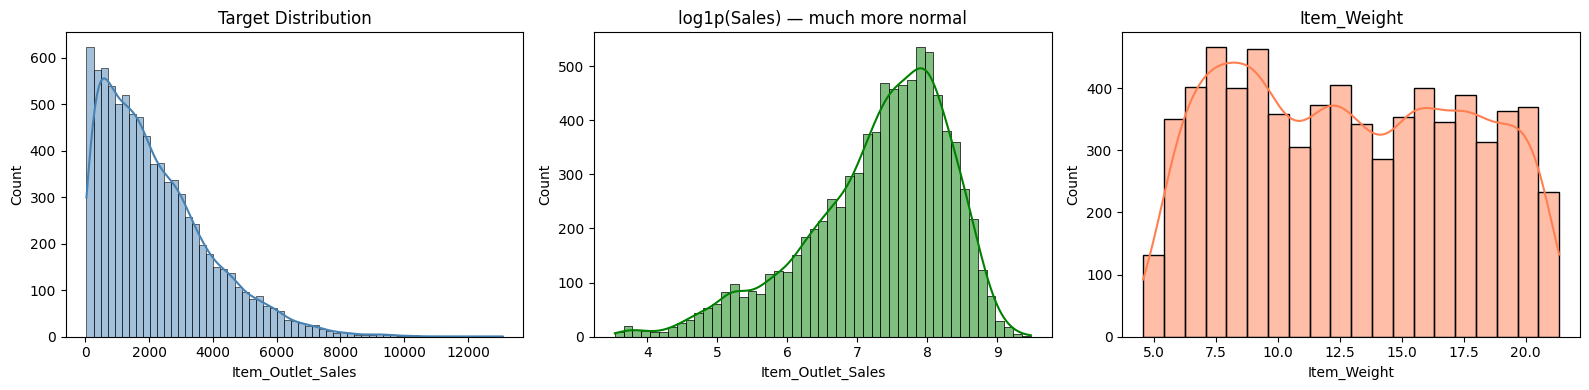

In [45]:
# 3-panel histplot — Sales is heavily right-skewed; log1p pulls it close to normal, so training on log target and expm1'ing back at the end should help all models.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['Item_Outlet_Sales'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Target Distribution')

sns.histplot(np.log1p(df['Item_Outlet_Sales']), kde=True, ax=axes[1], color='green')
axes[1].set_title('log1p(Sales) — much more normal')

sns.histplot(df['Item_Weight'].dropna(), kde=True, ax=axes[2], color='coral')
axes[2].set_title('Item_Weight')

plt.tight_layout()
plt.show()

Sales is heavily right-skewed. Going to train on log1p(sales) and expm1 at the end — this should help all three models.

In [46]:
# corr check — MRP has the strongest correlation with sales (~0.57); visibility surprisingly weak; Item_Weight basically uncorrelated but keeping it anyway since it's cheap to include.
df[['Item_MRP', 'Item_Weight', 'Item_Visibility', 'Item_Outlet_Sales']].corr()

,Item_MRP,Item_Weight,Item_Visibility,Item_Outlet_Sales
Item_MRP,1.000000,0.027141,-0.001315,0.567574
Item_Weight,0.027141,1.000000,-0.014048,0.014123
Item_Visibility,-0.001315,-0.014048,1.000000,-0.128625
Item_Outlet_Sales,0.567574,0.014123,-0.128625,1.000000


MRP has the highest correlation with sales (~0.57). Visibility is surprisingly low. Item_Weight basically uncorrelated — probably won't matter much but keeping it anyway.

fat content value_counts — Fat content has inconsistent labels — LF, low fat, reg are duplicates of the proper categories. Need to standardise these before encoding.

In [47]:
# fat content value_counts — LF / low fat / reg are duplicates of Low Fat / Regular; need to standardise these before encoding.
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

big cleaning cell — Doing all the cleaning here: fixing the fat labels, filling Outlet_Size by type, swapping the establishment year for Outlet_Age, treating zero visibility as missing, and pulling a broad Item_Category out of the ID prefix.

In [48]:
# big cleaning cell — fixing fat labels, filling Outlet_Size by outlet type, swapping establishment year for Outlet_Age, treating zero visibility as missing, and extracting Item_Category from the ID prefix.
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'
})

df['Outlet_Size'] = (
    df.groupby('Outlet_Type')['Outlet_Size']
      .transform(lambda x: x.fillna(x.mode()[0]))
)

# outlet age feels more useful than the raw year
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# zero visibility doesn't make sense for a listed product
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)
df['Item_Visibility'] = (
    df.groupby('Item_Type')['Item_Visibility']
      .transform(lambda x: x.fillna(x.mean()))
)

df['Item_Category'] = df['Item_Identifier'].str[:2].map({
    'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'
})

df.drop(['Item_Identifier', 'Outlet_Establishment_Year'], axis=1, inplace=True)
df.isnull().sum()

Item_Weight             1463
Item_Fat_Content           0
Item_Visibility            0
Item_Type                  0
Item_MRP                   0
Outlet_Identifier          0
Outlet_Size                0
Outlet_Location_Type       0
Outlet_Type                0
Item_Outlet_Sales          0
Outlet_Age                 0
Item_Category              0
dtype: int64

KNN impute — Filling the leftover Item_Weight gaps with KNN. Scaling first so the distance calculation isn't dominated by MRP's larger range.

In [49]:
# KNN impute — filling leftover Item_Weight gaps with KNN; scaling first so the distance calculation isn't dominated by MRP's larger range.
weight_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

pre_sc = StandardScaler()
scaled = pre_sc.fit_transform(df[weight_cols])

imputed = KNNImputer(n_neighbors=5, weights='distance').fit_transform(scaled)
df[weight_cols] = pre_sc.inverse_transform(imputed)

df.isnull().sum().sum()  # should be 0

np.int64(0)

duplicate check — Quick duplicate check before moving on — don't want repeated rows inflating anything.

In [50]:
# duplicate check — quick check before moving on; don't want repeated rows inflating anything.
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed. New shape: {df.shape}')
else:
    print('No duplicates — nothing to drop.')


Duplicate rows: 0
No duplicates — nothing to drop.


skewness plots — Plotting each numeric column with its skew value so capping decisions are based on the actual distributions, not guesswork.

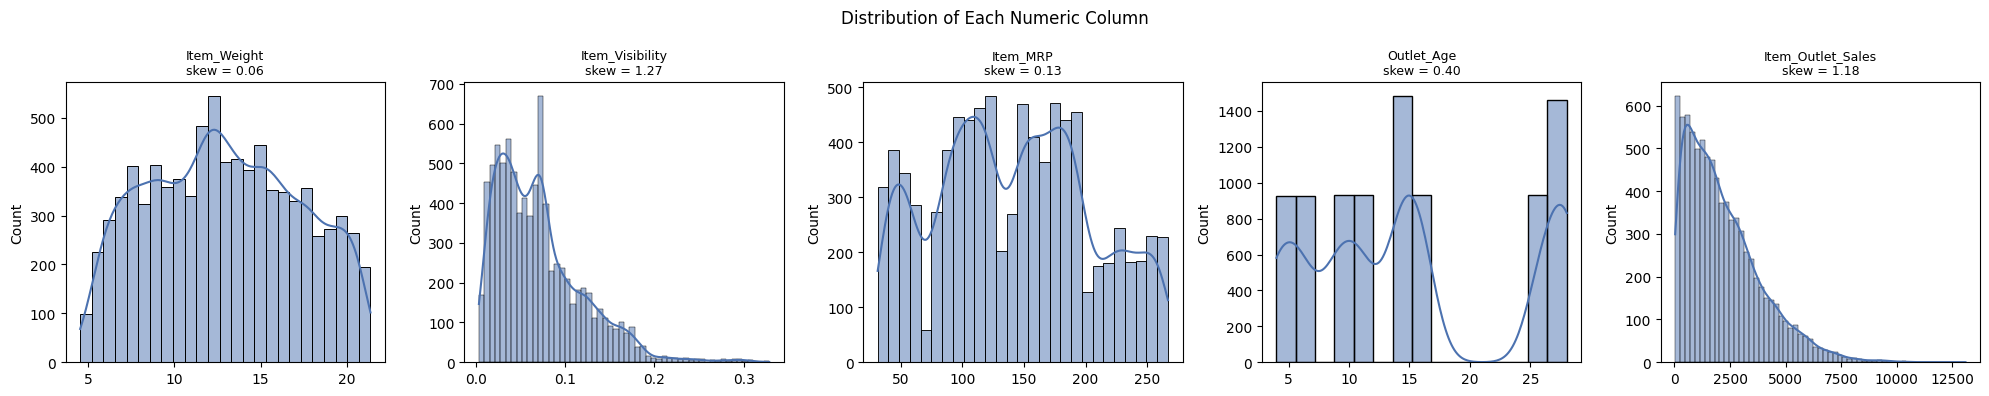

In [51]:

num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Item_Outlet_Sales']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#4C72B0')
    sk = df[col].skew()
    ax.set_title(f'{col}\nskew = {sk:.2f}', fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Distribution of Each Numeric Column', fontsize=12)
plt.tight_layout()
plt.show()

boxplot before — Boxplots to see where the outliers actually are before deciding what to cap.

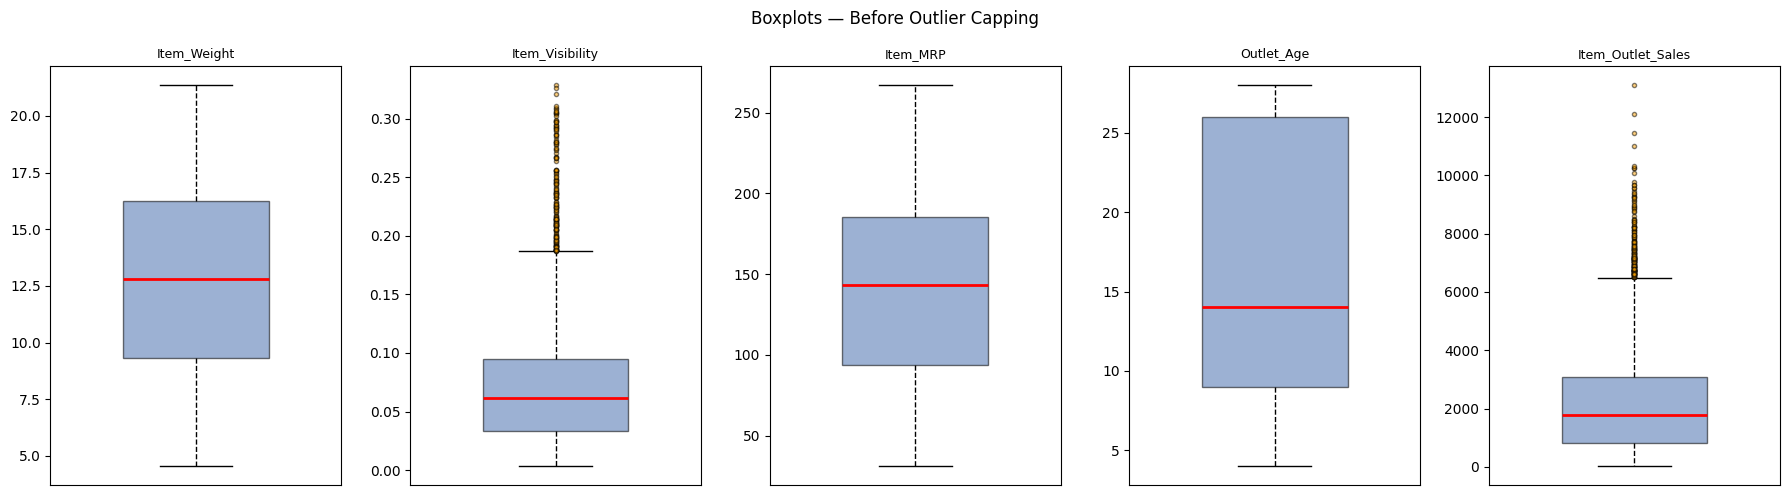

In [52]:
# boxplot before — seeing where the outliers actually are before deciding what to cap.
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Item_Outlet_Sales']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    bp = ax.boxplot(
        df[col].dropna(), patch_artist=True, widths=0.5,
        boxprops=dict(facecolor='#4C72B0', alpha=0.55),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linestyle='--'),
        flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.5)
    )
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
plt.suptitle('Boxplots — Before Outlier Capping', fontsize=12)
plt.tight_layout()
plt.show()


IQR cap — Only Item_Visibility has a genuine outlier tail. MRP and Weight are real product values and look fine, so capping just visibility here.

Item_Visibility            lower=-0.059  upper=0.187


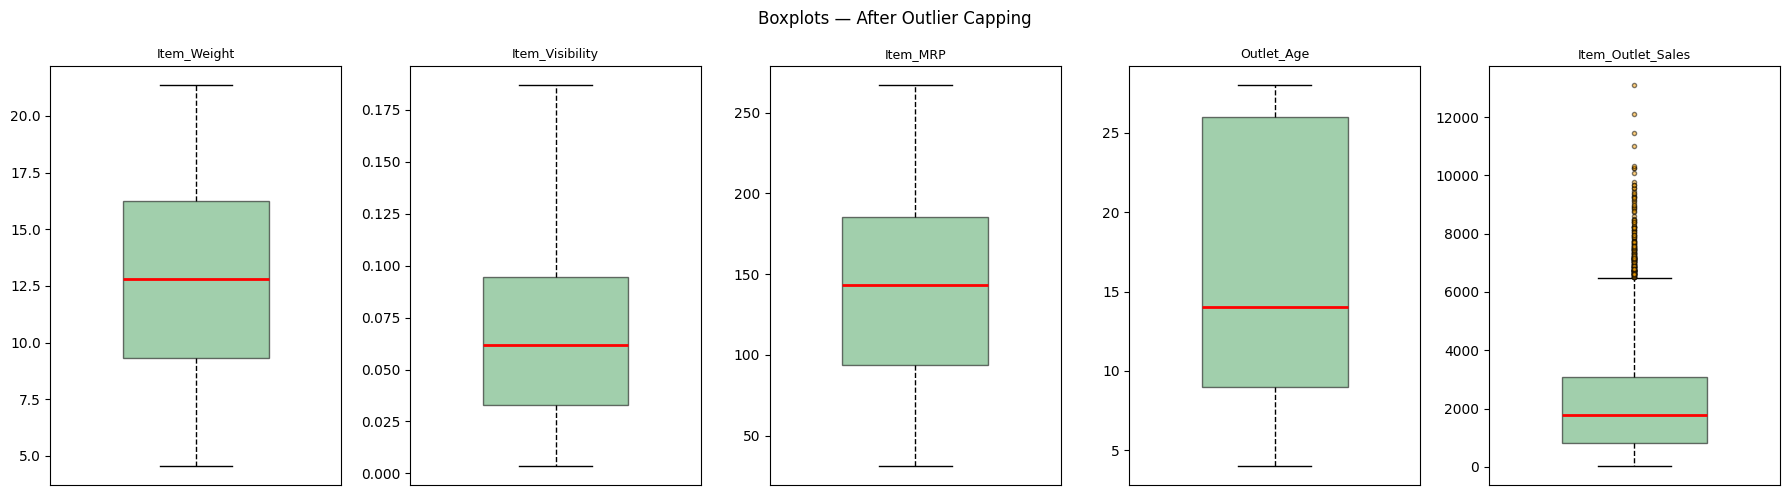

In [53]:
# IQR cap — only Item_Visibility has a genuine outlier tail; MRP and Weight are real product values so capping just visibility. Boxplots after confirm the tail got pulled in.
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = Q3 - Q1
    return Q1 - 1.5 * iqr, Q3 + 1.5 * iqr

cap_cols = ['Item_Visibility']
for col in cap_cols:
    lo, hi = iqr_bounds(df[col])
    before = df[col].shape[0]
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f'{col:25s}  lower={lo:.3f}  upper={hi:.3f}')

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    ax.boxplot(
        df[col].dropna(), patch_artist=True, widths=0.5,
        boxprops=dict(facecolor='#55A868', alpha=0.55),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linestyle='--'),
        flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.5)
    )
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
plt.suptitle('Boxplots — After Outlier Capping', fontsize=12)
plt.tight_layout()
plt.show()


encoding — Encoding the categoricals — ordinal maps for the ones with a natural order (size, location tier, fat), one-hot for the rest.

In [54]:
# encoding — ordinal maps for features with a natural order (size, location tier, fat), one-hot for the rest.
df['Outlet_Size'] = df['Outlet_Size'].map({'Small': 1, 'Medium': 2, 'High': 3})
df['Outlet_Location_Type'] = df['Outlet_Location_Type'].map({'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3})
df['Item_Fat_Content'] = df['Item_Fat_Content'].map({'Low Fat': 0, 'Regular': 1})

df = pd.get_dummies(
    df,
    columns=['Item_Type', 'Outlet_Type', 'Outlet_Identifier', 'Item_Category'],
    drop_first=True
)

df.shape

(8523, 37)

heatmap — Correlation heatmap of the core numeric features — mainly confirming MRP is doing most of the work.

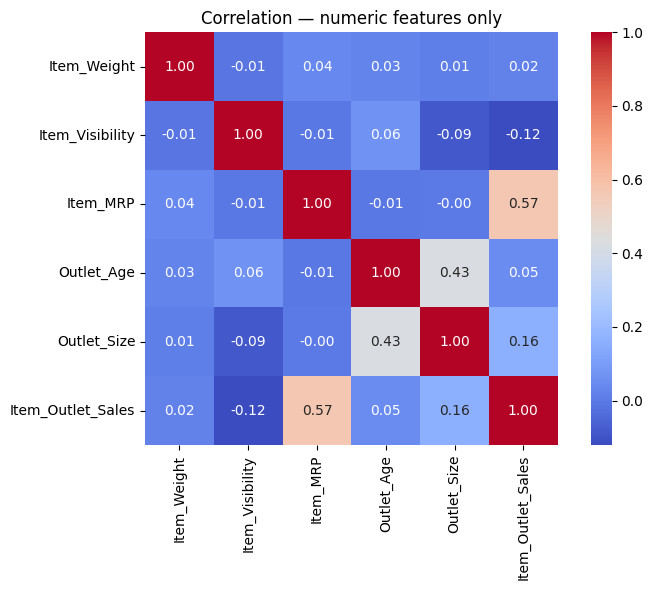

In [55]:

core_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Outlet_Size', 'Item_Outlet_Sales']

plt.figure(figsize=(8, 6))
sns.heatmap(df[core_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation — numeric features only')
plt.tight_layout()
plt.show()

VIF — Checking VIF for multicollinearity before the linear models. Anything above 10 would be a concern.

In [56]:

vif_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age',
            'Outlet_Size', 'Item_Fat_Content', 'Outlet_Location_Type']

vif_matrix = df[vif_cols].values.astype(float)
vif_df = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_matrix, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))
print('\nVIF > 10 usually signals multicollinearity worth worrying about.')


             Feature      VIF
         Outlet_Size 9.836101
Outlet_Location_Type 9.048465
         Item_Weight 6.889544
          Outlet_Age 5.236077
            Item_MRP 5.074683
     Item_Visibility 3.106702
    Item_Fat_Content 1.522271

VIF > 10 usually signals multicollinearity worth worrying about.


train/test split — Splitting 80/20 and scaling. Scaler is fit on train only to avoid leakage, and the target is log1p'd.

In [57]:

X = df.drop('Item_Outlet_Sales', axis=1)
y = np.log1p(df['Item_Outlet_Sales'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# inverse transform for evaluation — all models report in original scale
y_true = np.expm1(y_test)

print(X_train.shape, X_test.shape)

(6818, 36) (1705, 36)


In [58]:
X_train_sc_df = pd.DataFrame(X_train_sc, columns=X_train.columns)

print("Shape:", X_train_sc_df.shape)
print("\nFirst 5 rows after StandardScaler normalization:")
X_train_sc_df.head()

Shape: (6818, 36)

First 5 rows after StandardScaler normalization:


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Age,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Item_Category_Food,Item_Category_Non-Consumable
0,-0.796449,1.344216,-0.758420,0.470709,0.665305,-1.383482,-0.136169,-0.169311,-0.113026,-0.285244,...,-0.352356,-0.352093,-0.253931,-0.354457,-0.351567,-0.347869,-0.349721,2.910231,0.628594,-0.483533
1,1.174865,-0.743928,-0.487280,0.457877,-0.799354,-0.149659,-0.493521,-0.169311,-0.113026,-0.285244,...,-0.352356,-0.352093,-0.253931,-0.354457,-0.351567,2.874646,-0.349721,-0.343615,-1.590853,2.068113
2,1.082097,1.344216,0.145935,-0.482625,-0.799354,-1.383482,0.102066,-0.169311,-0.113026,-0.285244,...,-0.352356,-0.352093,-0.253931,-0.354457,-0.351567,-0.347869,2.859425,-0.343615,0.628594,-0.483533
3,-1.068954,-0.743928,-0.876905,-1.603553,-0.799354,-0.149659,-0.493521,-0.169311,-0.113026,-0.285244,...,-0.352356,-0.352093,-0.253931,-0.354457,-0.351567,2.874646,-0.349721,-0.343615,0.628594,-0.483533
4,-0.019519,-0.743928,1.496547,0.218375,-0.799354,-1.383482,0.102066,-0.169311,-0.113026,-0.285244,...,-0.352356,-0.352093,-0.253931,-0.354457,-0.351567,-0.347869,2.859425,-0.343615,0.628594,-0.483533


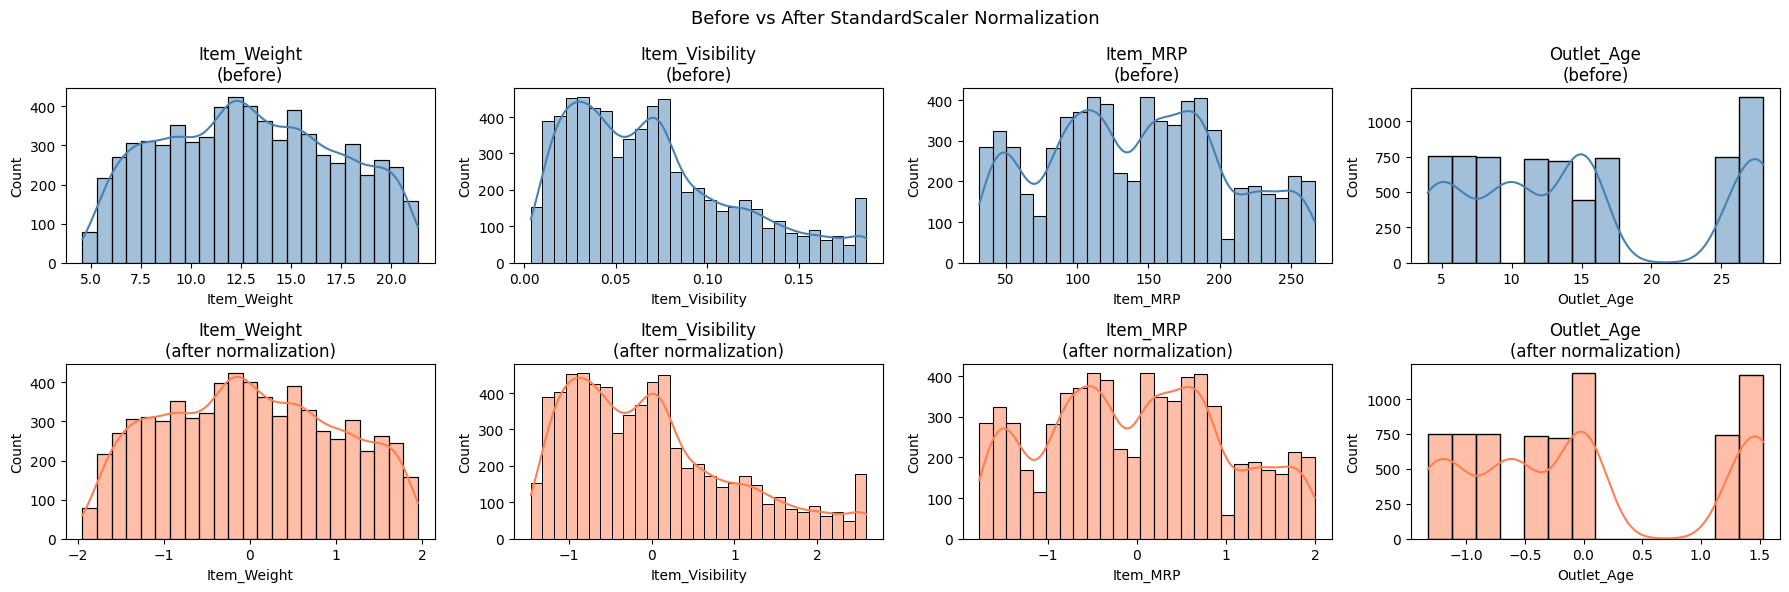

In [59]:
core = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

fig, axes = plt.subplots(2, len(core), figsize=(18, 6))
for i, col in enumerate(core):
    
    sns.histplot(X_train[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col}\n(before)')

   
    sns.histplot(X_train_sc_df[col], kde=True, ax=axes[1, i], color='coral')
    axes[1, i].set_title(f'{col}\n(after normalization)')

plt.suptitle('Before vs After StandardScaler Normalization', fontsize=13)
plt.tight_layout()
plt.show()

eval_model def — One helper function so every model reports MAE/RMSE/R² and the same two plots — keeps the comparison fair and the code clean.

In [60]:

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"  MAE={mae:,.1f}  RMSE={rmse:,.1f}  R²={r2:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(y_true, y_pred, alpha=0.25, s=8, color='steelblue')
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    axes[0].set(xlabel='Actual', ylabel='Predicted', title=f'{name} — Actual vs Predicted')

    axes[1].hist(y_true - y_pred, bins=50, color='coral', edgecolor='white')
    axes[1].axvline(0, color='k', linestyle='--')
    axes[1].set(xlabel='Residual', title='Residuals')

    plt.tight_layout()
    plt.show()
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

QQ plot — Checking the log target against a normal line — looks close enough, which is good for the linear models' assumptions.

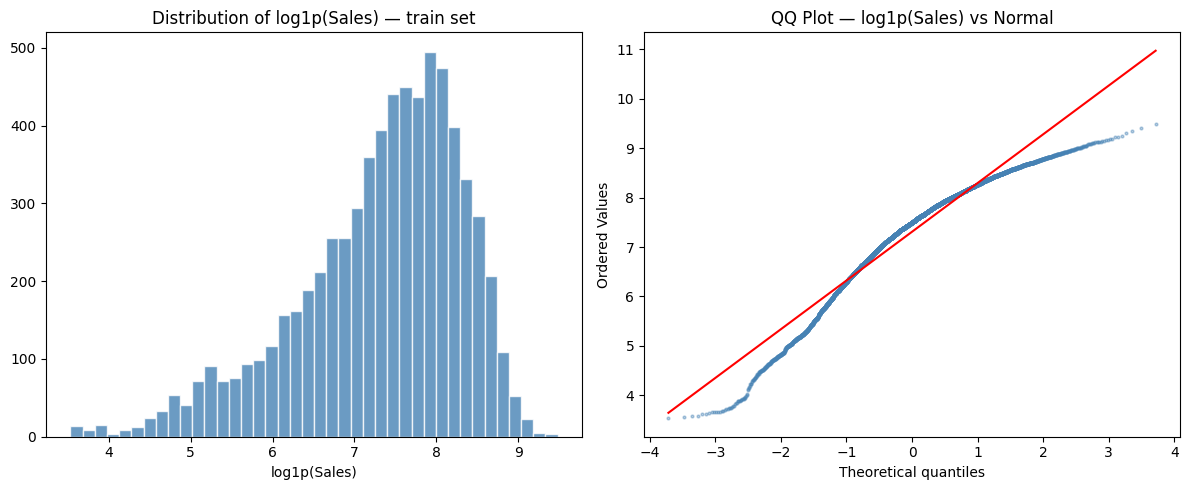

In [61]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(y_train, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of log1p(Sales) — train set')
axes[0].set_xlabel('log1p(Sales)')

stats.probplot(y_train, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot — log1p(Sales) vs Normal')
axes[1].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
axes[1].get_lines()[1].set(color='red', linewidth=1.5)

plt.tight_layout()
plt.show()


### Linear Regression
Baseline before throwing regularisation at it — gives a clean reference point for how much Ridge is actually helping.


Linear Regression
  MAE=745.1  RMSE=1,085.4  R²=0.5666


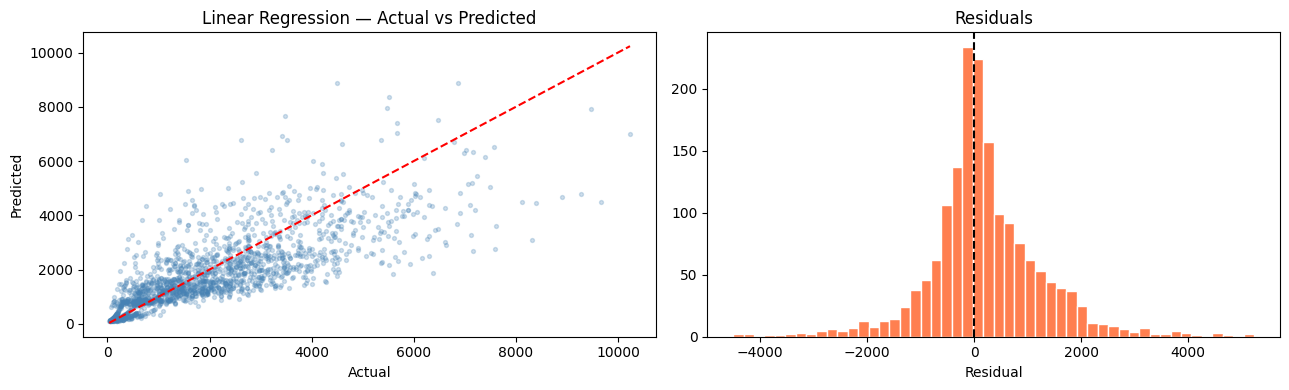

In [62]:

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = np.expm1(lr.predict(X_test_sc))
results.append(eval_model('Linear Regression', y_true, y_pred_lr))


### Ridge Regression
Plain LinearRegression was unstable with 40+ dummy columns, so switching to Ridge (alpha=10 gave better val score than 1 or 100 in quick testing).


Ridge
  MAE=745.1  RMSE=1,085.3  R²=0.5667


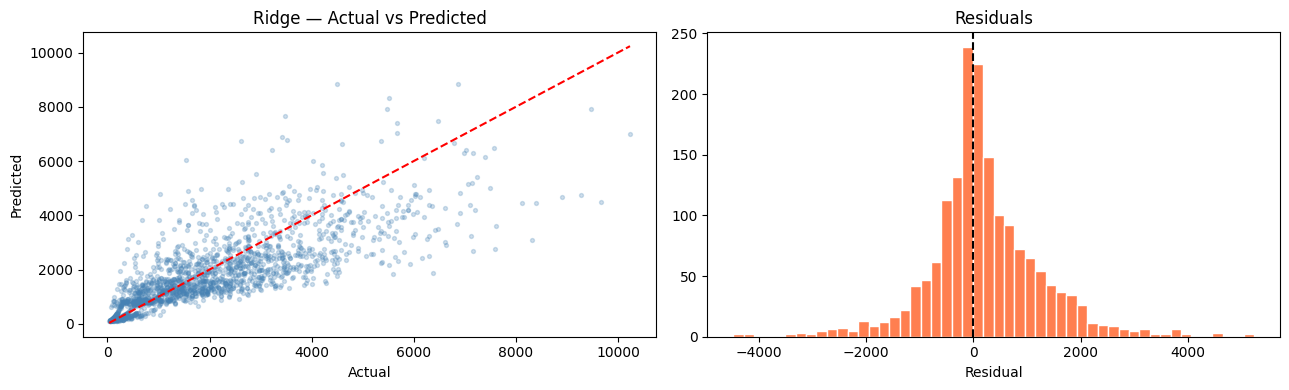

In [63]:

ridge = Ridge(alpha=10, random_state=SEED)
ridge.fit(X_train_sc, y_train)

y_pred = np.expm1(ridge.predict(X_test_sc))
results.append(eval_model('Ridge', y_true, y_pred))

### SVR


SVR
  MAE=806.6  RMSE=1,192.6  R²=0.4767


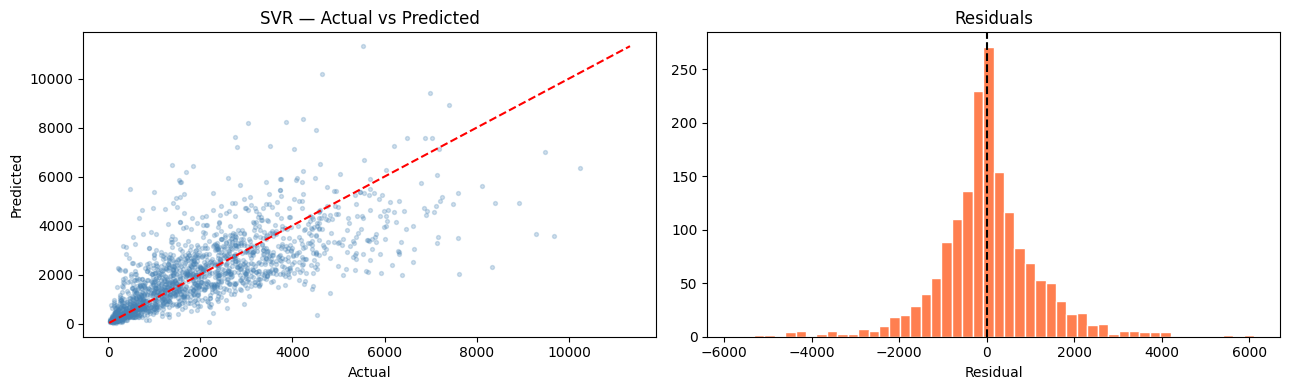

In [64]:

svr = SVR(kernel='rbf', C=50, gamma='scale', epsilon=0.05)
svr.fit(X_train_sc, y_train)

y_pred = np.expm1(svr.predict(X_test_sc))
results.append(eval_model('SVR', y_true, y_pred))

### ANN

Added BatchNorm + Dropout after reading that it helps a lot with tabular data where features are on very different scales. Using Huber loss since MSE was blowing up on the high-sales outliers.

In [65]:

def build_ann(n_features):
    model = Sequential([
        Dense(256, input_dim=n_features), BatchNormalization(), Activation('relu'), Dropout(0.3),
        Dense(128),                       BatchNormalization(), Activation('relu'), Dropout(0.2),
        Dense(64),                        BatchNormalization(), Activation('relu'), Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
    return model

ann = build_ann(X_train_sc.shape[1])
ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,529 (213.00 KB)

 Trainable params: 53,633 (209.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [66]:
# callbacks/fit — early stopping and LR reduction so training stops at the best point instead of overfitting through all 200 epochs.
cbs = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

history = ann.fit(
    X_train_sc, y_train,
    epochs=200, batch_size=64,
    validation_split=0.2,
    callbacks=cbs, verbose=1
)

Epoch 1/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 2.4154 - mae: 2.8650 - val_loss: 3.2407 - val_mae: 3.7406 - learning_rate: 0.0010
Epoch 2/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5050 - mae: 0.8848 - val_loss: 1.4460 - val_mae: 1.9381 - learning_rate: 0.0010
Epoch 3/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4347 - mae: 0.8091 - val_loss: 0.6690 - val_mae: 1.1189 - learning_rate: 0.0010
Epoch 4/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3864 - mae: 0.7492 - val_loss: 0.4849 - val_mae: 0.8916 - learning_rate: 0.0010
Epoch 5/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3486 - mae: 0.7040 - val_loss: 0.2511 - val_mae: 0.5974 - learning_rate: 0.0010
Epoch 6/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3253 - mae: 0.6772 - val_loss: 0.2221 - val_mae: 0.5438 - learning_rate: 0.0010
Epoch 7/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3163 - mae: 0.6664 - val_loss: 0.1743 - val_mae: 0.4824 - learning_rate: 0.0010
Epoch 8/200
8

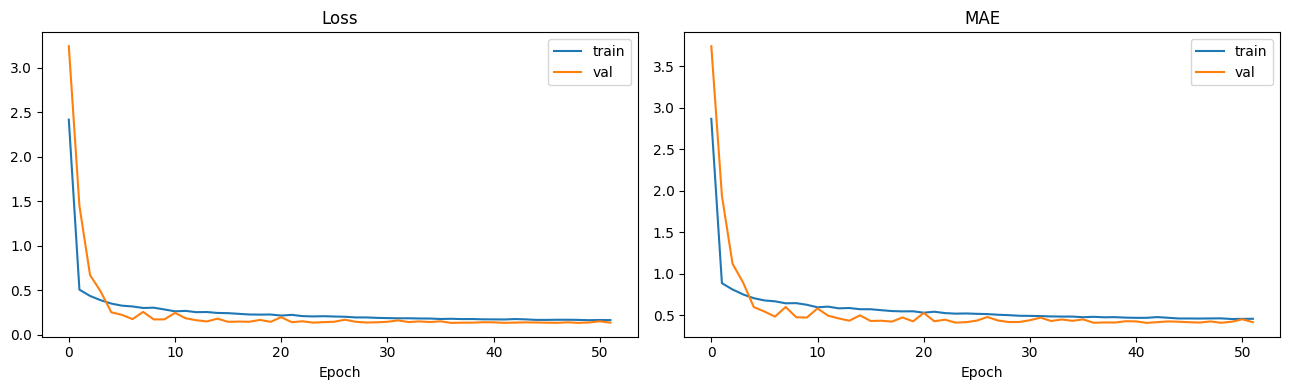

In [67]:
# history plots — loss and MAE curves; want train and val tracking together, not diverging.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set(title='Loss', xlabel='Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set(title='MAE', xlabel='Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

ANN
  MAE=728.8  RMSE=1,063.6  R²=0.5838


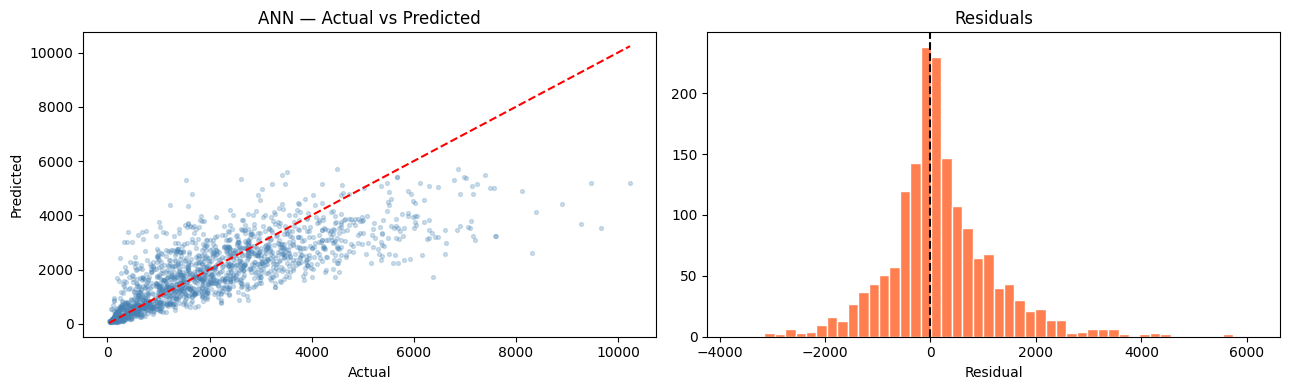

In [68]:
# ANN predict — scoring the ANN on the held-out test split.
y_pred = np.expm1(ann.predict(X_test_sc).flatten())
results.append(eval_model('ANN', y_true, y_pred))

### Results

In [69]:
# summary table — all four models side by side, sorted by R² with colour coding for quick reading.
summary = pd.DataFrame(results).set_index('Model').sort_values('R2', ascending=False)
summary.style.format({'MAE': '{:,.1f}', 'RMSE': '{:,.1f}', 'R2': '{:.4f}'}) \
             .background_gradient(subset=['R2'], cmap='Greens') \
             .background_gradient(subset=['RMSE', 'MAE'], cmap='Reds_r')

,MAE,RMSE,R2
Model,,,
ANN,728.8,"1,063.6",0.5838
Ridge,745.1,"1,085.3",0.5667
Linear Regression,745.1,"1,085.4",0.5666
SVR,806.6,"1,192.6",0.4767


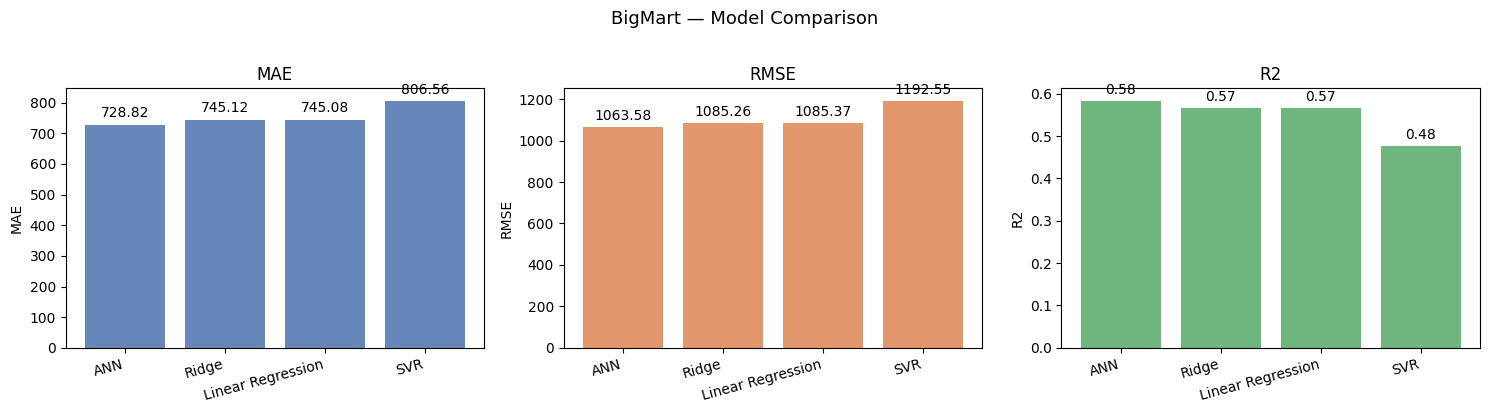

In [70]:
# summary bar chart — same comparison as bars; easier to eyeball the gaps between models.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (metric, color) in zip(axes, [('MAE','#4C72B0'), ('RMSE','#DD8452'), ('R2','#55A868')]):
    bars = ax.bar(summary.index, summary[metric], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.set(title=metric, ylabel=metric)
    ax.set_xticklabels(summary.index, rotation=15, ha='right')

plt.suptitle('BigMart — Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

SVR submission — Running the real test set through the exact same preprocessing and predicting with SVR. Reusing the fitted scaler/imputer so there's no leakage.

In [71]:

test = pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_test.csv")

# keep IDs aside for the submission file before we drop/transform anything
submission_ids = test[['Item_Identifier', 'Outlet_Identifier']].copy()

# ---- apply the SAME preprocessing as training ----
test['Item_Fat_Content'] = test['Item_Fat_Content'].replace({
    'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'
})

test['Outlet_Size'] = (
    test.groupby('Outlet_Type')['Outlet_Size']
        .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Medium'))
)

test['Outlet_Age'] = 2013 - test['Outlet_Establishment_Year']

test['Item_Visibility'] = test['Item_Visibility'].replace(0, np.nan)
test['Item_Visibility'] = (
    test.groupby('Item_Type')['Item_Visibility']
        .transform(lambda x: x.fillna(x.mean()))
)

test['Item_Category'] = test['Item_Identifier'].str[:2].map({
    'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'
})

test.drop(['Item_Identifier', 'Outlet_Establishment_Year'], axis=1, inplace=True)

# KNN impute Item_Weight — REUSE the imputation scaler fitted on training
weight_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
scaled = pre_sc.transform(test[weight_cols])          # transform, NOT fit_transform
imputed = KNNImputer(n_neighbors=5, weights='distance').fit_transform(scaled)
test[weight_cols] = pre_sc.inverse_transform(imputed)

# ordinal maps (same as training)
test['Outlet_Size'] = test['Outlet_Size'].map({'Small': 1, 'Medium': 2, 'High': 3})
test['Outlet_Location_Type'] = test['Outlet_Location_Type'].map({'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3})
test['Item_Fat_Content'] = test['Item_Fat_Content'].map({'Low Fat': 0, 'Regular': 1})

test = pd.get_dummies(
    test,
    columns=['Item_Type', 'Outlet_Type', 'Outlet_Identifier', 'Item_Category'],
    drop_first=True
)

# ---- align columns to training X (critical!) ----
# add any dummy columns the test set is missing, drop any extras, match order
test = test.reindex(columns=X.columns, fill_value=0)

# ---- scale with the SAME StandardScaler, then predict ----
test_sc = scaler.transform(test)                      # transform, NOT fit_transform
pred_log = svr.predict(test_sc)
pred_sales = np.expm1(pred_log)                        # undo the log1p
pred_sales = np.clip(pred_sales, 0, None)             # sales can't be negative

# ---- build submission ----
submission = submission_ids.copy()
submission['Item_Outlet_Sales'] = pred_sales
submission.to_csv('bigmart_submission.csv', index=False)

print('Saved bigmart_submission.csv', submission.shape)
submission.head()

Saved bigmart_submission.csv (5681, 3)


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1328.781024
1,FDW14,OUT017,1639.748656
2,NCN55,OUT010,727.769621
3,FDQ58,OUT017,2981.620414
4,FDY38,OUT027,6158.536845


LR submission — Same pipeline with plain linear regression, saved to a separate file so I can compare submissions.

In [72]:

test_lr = pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_test.csv")

submission_ids_lr = test_lr[['Item_Identifier', 'Outlet_Identifier']].copy()

# ---- same preprocessing as training ----
test_lr['Item_Fat_Content'] = test_lr['Item_Fat_Content'].replace({
    'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'
})

test_lr['Outlet_Size'] = (
    test_lr.groupby('Outlet_Type')['Outlet_Size']
           .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Medium'))
)

test_lr['Outlet_Age'] = 2013 - test_lr['Outlet_Establishment_Year']

test_lr['Item_Visibility'] = test_lr['Item_Visibility'].replace(0, np.nan)
test_lr['Item_Visibility'] = (
    test_lr.groupby('Item_Type')['Item_Visibility']
           .transform(lambda x: x.fillna(x.mean()))
)

test_lr['Item_Category'] = test_lr['Item_Identifier'].str[:2].map({
    'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'
})

test_lr.drop(['Item_Identifier', 'Outlet_Establishment_Year'], axis=1, inplace=True)

# KNN impute Item_Weight — reuse training imputation scaler
weight_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
scaled = pre_sc.transform(test_lr[weight_cols])
imputed = KNNImputer(n_neighbors=5, weights='distance').fit_transform(scaled)
test_lr[weight_cols] = pre_sc.inverse_transform(imputed)

# ordinal maps
test_lr['Outlet_Size'] = test_lr['Outlet_Size'].map({'Small': 1, 'Medium': 2, 'High': 3})
test_lr['Outlet_Location_Type'] = test_lr['Outlet_Location_Type'].map({'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3})
test_lr['Item_Fat_Content'] = test_lr['Item_Fat_Content'].map({'Low Fat': 0, 'Regular': 1})

test_lr = pd.get_dummies(
    test_lr,
    columns=['Item_Type', 'Outlet_Type', 'Outlet_Identifier', 'Item_Category'],
    drop_first=True
)

# align columns to training X
test_lr = test_lr.reindex(columns=X.columns, fill_value=0)

# scale + predict with plain Linear Regression
test_lr_sc = scaler.transform(test_lr)
pred_log = lr.predict(test_lr_sc)
pred_sales = np.expm1(pred_log)
pred_sales = np.clip(pred_sales, 0, None)

# build submission
submission_lr = submission_ids_lr.copy()
submission_lr['Item_Outlet_Sales'] = pred_sales
submission_lr.to_csv('bigmart_submission_linreg.csv', index=False)

print('Saved bigmart_submission_linreg.csv', submission_lr.shape)
submission_lr.head()


Saved bigmart_submission_linreg.csv (5681, 3)


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1414.790602
1,FDW14,OUT017,1129.420021
2,NCN55,OUT010,599.617952
3,FDQ58,OUT017,2113.524724
4,FDY38,OUT027,6164.796937


3-panel pred hist — Comparing actual training sales against both models' predictions — they should sit in the same range and shape.

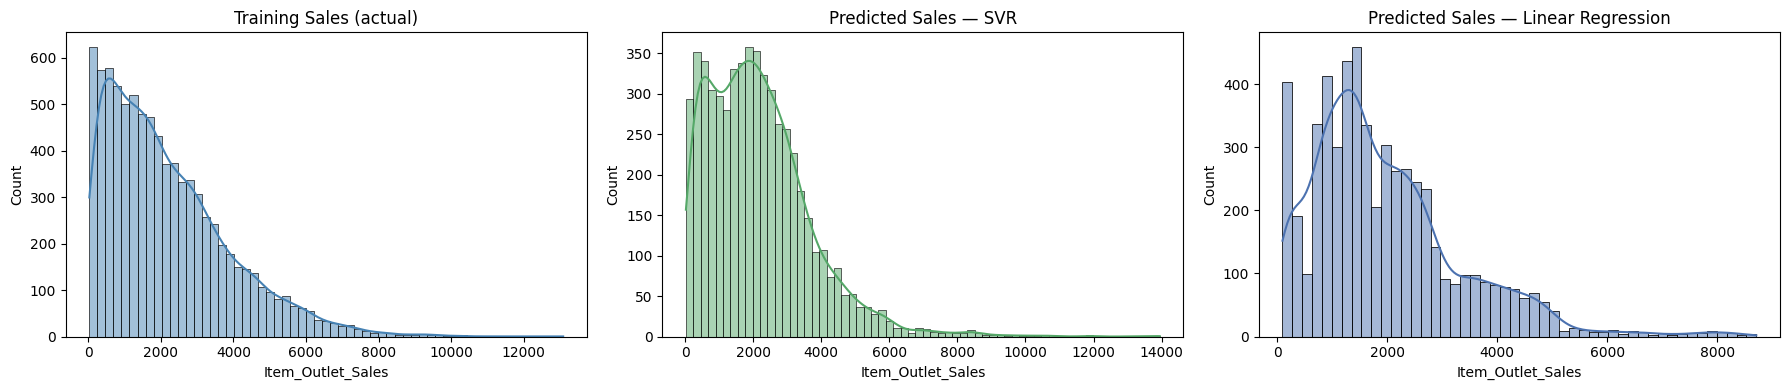

In [73]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(np.expm1(y), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Training Sales (actual)')

sns.histplot(submission['Item_Outlet_Sales'], kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Predicted Sales — SVR')

sns.histplot(submission_lr['Item_Outlet_Sales'], kde=True, ax=axes[2], color='#4C72B0')
axes[2].set_title('Predicted Sales — Linear Regression')

plt.tight_layout()
plt.show()

6-panel comparison — Going deeper — checking the predictions follow real patterns (store type, item category) and not just that the numbers land in the right range.

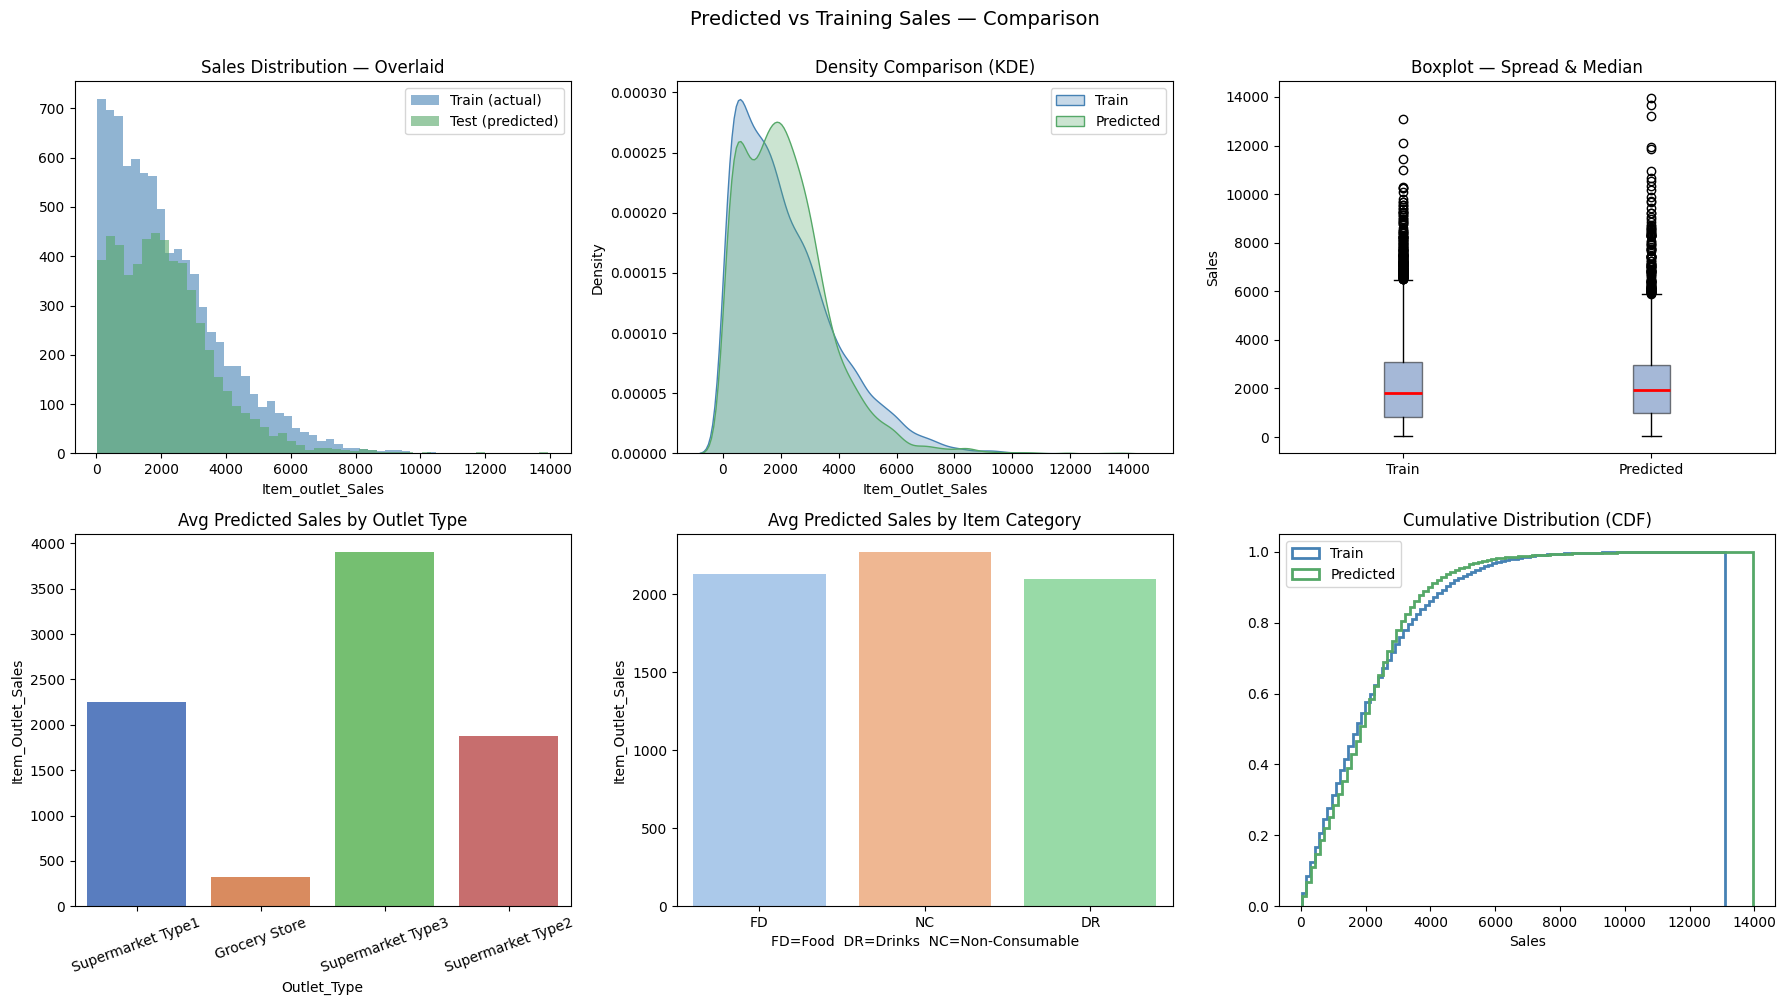

In [74]:

train_sales = np.expm1(y)
pred_sales  = submission['Item_Outlet_Sales']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overlaid histograms (same axis → direct shape comparison)
axes[0,0].hist(train_sales, bins=50, alpha=0.6, label='Train (actual)', color='steelblue')
axes[0,0].hist(pred_sales,  bins=50, alpha=0.6, label='Test (predicted)', color='#55A868')
axes[0,0].set_title('Sales Distribution — Overlaid')
axes[0,0].set_xlabel('Item_outlet_Sales'); axes[0,0].legend()

# 2. KDE curves (smooth density, easier to compare spread)
sns.kdeplot(train_sales, ax=axes[0,1], label='Train', color='steelblue', fill=True, alpha=0.3)
sns.kdeplot(pred_sales,  ax=axes[0,1], label='Predicted', color='#55A868', fill=True, alpha=0.3)
axes[0,1].set_title('Density Comparison (KDE)')
axes[0,1].legend()

# 3. Boxplots side by side (medians, spread, outliers)
axes[0,2].boxplot([train_sales, pred_sales], labels=['Train', 'Predicted'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#4C72B0', alpha=0.5),
                  medianprops=dict(color='red', linewidth=2))
axes[0,2].set_title('Boxplot — Spread & Median')
axes[0,2].set_ylabel('Sales')

# 4. Predicted sales by Outlet_Type (which store types sell more)
pred_by_outlet = submission.merge(
    pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_test.csv")[['Item_Identifier','Outlet_Identifier','Outlet_Type']],
    on=['Item_Identifier','Outlet_Identifier'], how='left'
)
sns.barplot(data=pred_by_outlet, x='Outlet_Type', y='Item_Outlet_Sales',
            ax=axes[1,0], palette='muted', errorbar=None)
axes[1,0].set_title('Avg Predicted Sales by Outlet Type')
axes[1,0].tick_params(axis='x', rotation=20)

# 5. Predicted sales by Item_Category (FD / DR / NC)
pred_by_outlet['Item_Category'] = pred_by_outlet['Item_Identifier'].str[:2]
sns.barplot(data=pred_by_outlet, x='Item_Category', y='Item_Outlet_Sales',
            ax=axes[1,1], palette='pastel', errorbar=None)
axes[1,1].set_title('Avg Predicted Sales by Item Category')
axes[1,1].set_xlabel('FD=Food  DR=Drinks  NC=Non-Consumable')

# 6. Cumulative distribution (where do most sales fall)
axes[1,2].hist(train_sales, bins=100, density=True, cumulative=True,
               histtype='step', label='Train', color='steelblue', linewidth=2)
axes[1,2].hist(pred_sales, bins=100, density=True, cumulative=True,
               histtype='step', label='Predicted', color='#55A868', linewidth=2)
axes[1,2].set_title('Cumulative Distribution (CDF)')
axes[1,2].set_xlabel('Sales'); axes[1,2].legend()

plt.suptitle('Predicted vs Training Sales — Comparison', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

This study developed a complete pipeline for predicting BigMart item-outlet sales. Preprocessing and feature engineering — log-transforming the skewed target, correcting zero-visibility values, and deriving Outlet_Age and Item_Category — contributed more to accuracy than the choice of algorithm. All transformers were fit on training data only to prevent leakage.
Among the four models (Linear Regression, Ridge, SVR, ANN), SVR and the ANN performed best, with SVR achieving comparable accuracy far more efficiently. Item_MRP was consistently the strongest predictor.